First visualization of some images from the dataset

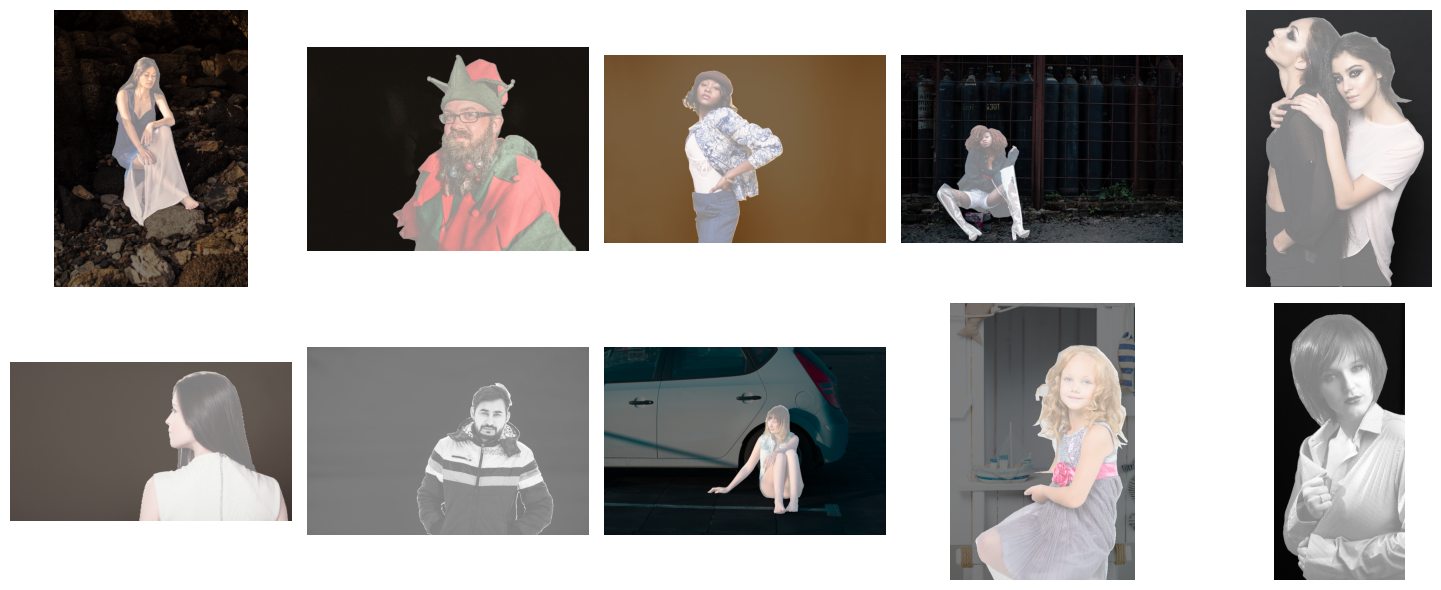

In [1]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

path = "./data/supervisely_person_clean_2667_img/images"
path_mask = "./data/supervisely_person_clean_2667_img/masks"


png_files = [f for f in os.listdir(path) if f.endswith('.png')]

random_images = random.sample(png_files, min(10, len(png_files)))


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, img_name in enumerate(random_images):
    img_path = os.path.join(path, img_name)
    img = Image.open(img_path)

    path_mask_img = os.path.join(path_mask, img_name)
    mask = Image.open(path_mask_img)
    
    axes[idx].imshow(img)
    axes[idx].imshow(mask, alpha=0.5) 
    axes[idx].axis('off')
    
    

plt.tight_layout()
plt.show()

todo:
prendi due pixel uno bianco e uno nero di un immagine. crea un immagine quadrata con estremi quei due punti. 
creare le background e image patches.

Poi creeremo un classifier che data una patch, stabilisce a che classe appartiene

In [2]:
import numpy as np
import os
from PIL import Image

def pick_random_centers(mask, size=100, ignore=0):
    #Ignoring borders
    mask_ignored = mask.copy()
    mask_ignored[:ignore, :] = False
    mask_ignored[-ignore:, :] = False
    mask_ignored[:, :ignore] = False
    mask_ignored[:, -ignore:] = False
    
    rs, cs = np.where(mask_ignored)
    
    if len(rs) == 0:
        return np.array([]), np.array([])
    
    ix = np.random.randint(len(rs), size=min(size, len(rs)))
    return rs[ix], cs[ix]

def extract_patches_from_image(img_array, mask_array, n_patches_per_class, radius):
    patches = []
    labels = []
    
    # Converti maschera in booleano
    mask_bool = mask_array > 127
    
    # Estrai patch TRUE (persona)
    rs, cs = pick_random_centers(mask_bool, size=n_patches_per_class, ignore=radius)
    for r, c in zip(rs, cs):
        patch = img_array[r-radius:r+radius, c-radius:c+radius, :]
        patches.append(patch.flatten())
        labels.append(1)
    
    # Estrai patch FALSE (background)
    rs, cs = pick_random_centers(~mask_bool, size=n_patches_per_class, ignore=radius)
    for r, c in zip(rs, cs):
        patch = img_array[r-radius:r+radius, c-radius:c+radius, :]
        patches.append(patch.flatten())
        labels.append(0)
    
    return patches, labels


def create_patch_dataset(image_files, path_img, path_mask, radius, n_patches_per_class):
    X = []
    y = []
    
    for img_name in image_files:
        img = Image.open(os.path.join(path_img, img_name))
        mask = Image.open(os.path.join(path_mask, img_name))
        
        img_array = np.array(img)
        mask_array = np.array(mask)
        
        # patch extraction
        patches, labels = extract_patches_from_image(img_array, mask_array, 
                                                     n_patches_per_class, radius)
        
        X.extend(patches)
        y.extend(labels)
    
    return np.array(X), np.array(y)



In [ ]:
import keras
import keras.layers
import tensorflow as tf

def mkmodel():
    input_layer = keras.Input(shape=(None, None, 3), name='input')

    # --- ENCODER ---
    # First block
    x = keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(input_layer)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)# Efficient conv
    # Convoluzione Separabile: Divide il lavoro in due passaggi più semplici:
    # - Depthwise: Analizza solo lo spazio (forme, bordi) canale per canale.
    # - Pointwise (1x1): Mescola i canali (colori, feature) tra loro.

    x = keras.layers.BatchNormalization()(x)
    x1 = x # Save for skip connection
    
    # Downsample
    x = keras.layers.MaxPooling2D(2)(x) 
    # Lavora sull'immagine rimpicciolita. 
    # Cerca forme più complesse (occhi, mani). Usa 64 filtri (più "neuroni" per capire meglio).

    # Instead of 4-8... filters, we start with 32 and go up to 128. 
    # This provides more capacity to learn complex features

    # Second block
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x2 = x # Save for skip connection
    
    # Downsample
    x = keras.layers.MaxPooling2D(2)(x) 

    # Bottleneck - the most abstract features. Qui l'immagine e' molto rimpicciolita
    x = keras.layers.SeparableConv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)

    # --- DECODER ---
    #
    # il modello torna alle dimensioni originali per dipingere la mask.

    # Upsample and Skip Connection 1
    x = keras.layers.UpSampling2D(2)(x)
    x = keras.layers.Concatenate()([x, x2]) # Il modello prende quello che ha capito (dal cervello) e lo unisce alle info dettagliate salvate prima 
    
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x) 
    x = keras.layers.BatchNormalization()(x)

    # Upsample and Skip Connection 2
    x = keras.layers.UpSampling2D(2)(x)
    x = keras.layers.Concatenate()([x, x1])
    
    x = keras.layers.SeparableConv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)

    # Output layer
    x = keras.layers.Conv2D(filters=1, kernel_size=(1,1), padding='same', activation='sigmoid')(x)
    
    return keras.Model(input_layer, x)

# Creating the model
model = mkmodel()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Lower LR usually better for deeper nets
              loss=keras.losses.BinaryCrossentropy(from_logits=False), 
              metrics=[keras.metrics.BinaryAccuracy()])

model.summary()

Il modello ha una forma a "U": prima rimpicciolisce l'immagine per capirne il contenuto (Encoder), poi la ingrandisce per creare la maschera finale (Decoder).

ENCODER:
Questa parte serve a capire "COSA" c'è nell'immagine ("c'è una persona"), sacrificando il "DOVE" (i dettagli precisi).